# PF-5039: Semana 01 - Práctica Asincrónica Desafío Avanzado
## Simulación de Aliasing Espacial, Filtro Antialiasing y Evaluación de PSNR en Retinografía

**Estudiante:** _____________________ **Carné:** ____________

---
### Requerimientos del Desafío:
En esta práctica autónoma de 1 hora, estudiará en detalle cómo prevenir el fenómeno de Aliasing/Moiré en imágenes médicas de alta densidad cromática.

--- 
### Parte A: Simulación de Aliasing en una Grilla Sinusoidal Sintética
1. Genere una matriz de $512 \times 512$ píxeles representando la función matemática $f(x, y) = \sin(2\pi f_0 x) + \sin(2\pi f_0 y)$ con $f_0 = 15$.
2. Aplique un submuestreo por un factor de escala $S = 4$ mediante dos métodos:
   - **Método 1 (Submuestreo Directo sin Filtrado):** Tome cada $S$-ésimo píxel directo de la matriz (`pattern[::S, ::S]`).
   - **Método 2 (Submuestreo Filtrado Antialiasing):** Aplique un filtro pasa-bajo Gaussiano (`cv2.GaussianBlur`) con $\sigma = S/2 = 2.0$ y luego submuestree.
3. Grafique los 3 mapas de intensidad en paralelo e interpete la presencia de patrones Moiré.

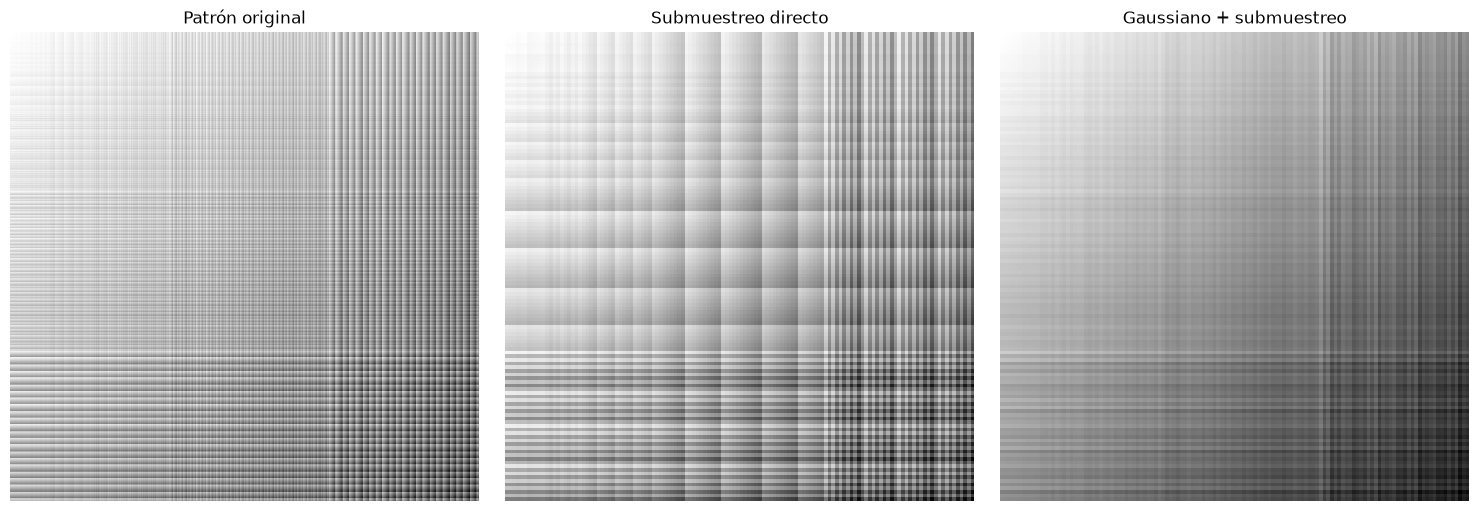

In [60]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# PUNTO 1: Generación del patrón sinusoidal
# ============================================================

# Parámetros principales
N = 512   # Número de muestras (píxeles) en cada dimensión de la imagen.
f0 = 15   # Frecuencia utilizada en la función sinusoidal indicada en el enunciado.


# Generación de los vectores de coordenadas.
# x representa las posiciones horizontales de la imagen.
# y representa las posiciones verticales de la imagen.
#
# Como N = 512, ambos vectores contienen los valores:
# 0, 1, 2, ..., 511.
#
# La separación entre dos posiciones consecutivas es de 1 unidad.

x = np.arange(N)
y = np.arange(N)


# Conversión de los vectores x e y en una cuadrícula bidimensional.
#
# X contiene la coordenada horizontal correspondiente a cada píxel.
# Y contiene la coordenada vertical correspondiente a cada píxel.
#
# Por ejemplo:
#
# X = [[0, 1, 2, ...],
#      [0, 1, 2, ...],
#      [0, 1, 2, ...]]
#
# Y = [[0, 0, 0, ...],
#      [1, 1, 1, ...],
#      [2, 2, 2, ...]]
#
# Ambas matrices tienen dimensiones 512 x 512.

X, Y = np.meshgrid(x, y)


# Generación del patrón sinusoidal.
#
# Se evalúa en cada posición (x, y) la función indicada:
#
# f(x,y) = sin(2*pi*f0*x) + sin(2*pi*f0*y)
#
# El primer término depende de la coordenada horizontal X.
# El segundo término depende de la coordenada vertical Y.
#
# El resultado f es una única matriz de 512 x 512 valores,
# que representa el mapa de intensidad del patrón.

f = np.sin(2 * np.pi * f0 * X) + np.sin(2 * np.pi * f0 * Y)



# ============================================================
# PUNTO 2: Submuestreo de la imagen
# ============================================================

# Factor de submuestreo.
#
# S = 4 significa que se conservará una muestra de cada cuatro
# tanto en la dirección horizontal como en la vertical.

S = 4


# ------------------------------------------------------------
# MÉTODO 1: Submuestreo directo sin filtrado
# ------------------------------------------------------------

# [::S, ::S] selecciona:
#
# - una fila de cada 4;
# - una columna de cada 4.
#
# Por ejemplo, se conservan las posiciones:
# 0, 4, 8, 12, ...
#
# Como la imagen original mide 512 x 512:
#
# 512 / 4 = 128
#
# la nueva matriz tendrá dimensiones 128 x 128.

pattern_subsampled = f[::S, ::S]


# ------------------------------------------------------------
# MÉTODO 2: Filtro Gaussiano + submuestreo
# ------------------------------------------------------------

# El filtro Gaussiano se aplica antes de eliminar muestras.
# Su objetivo es suavizar las variaciones espaciales rápidas
# que podrían producir aliasing después del submuestreo.
#
# El enunciado establece:
#
# sigma = S / 2 = 2

sigma = S / 2


# Aplicación del filtro Gaussiano.
#
# f:
#     matriz original que será filtrada.
#
# (0, 0):
#     indica que no se especificará manualmente el tamaño
#     del kernel. OpenCV lo determina automáticamente
#     utilizando el valor de sigma.
#
# sigmaX=sigma:
#     establece la desviación estándar del filtro Gaussiano
#     en la dirección horizontal.
#
# El resultado se almacena en f_filtrada.

f_filtrada = cv2.GaussianBlur(f, (0, 0), sigmaX=sigma)


# Una vez filtrada la matriz, se realiza el mismo
# submuestreo utilizado en el Método 1.
#
# Se conserva una fila de cada 4 y una columna de cada 4.
#
# La matriz resultante también tendrá dimensiones 128 x 128.

f_subsampled_gaussian = f_filtrada[::S, ::S]



# ============================================================
# PUNTO 3: Visualización de los resultados
# ============================================================

# Se crea una figura que contiene tres espacios para imágenes.
#
# 1, 3:
#     indica que habrá 1 fila y 3 columnas.
#
# fig:
#     representa la figura completa.
#
# axes:
#     contiene los tres espacios individuales donde se
#     colocarán las imágenes.
#
# figsize=(15, 5):
#     establece únicamente el tamaño visual de la figura:
#     15 pulgadas de ancho y 5 pulgadas de alto.

fig, axes = plt.subplots(1, 3, figsize=(15, 5))


# ------------------------------------------------------------
# Mapa 1: Patrón original
# ------------------------------------------------------------

# imshow() interpreta la matriz f como una imagen.
#
# cmap="gray" representa sus valores utilizando
# una escala de grises.

axes[0].imshow(f, cmap="gray")

# Título mostrado encima de la primera imagen.
axes[0].set_title("Patrón original")

# Se ocultan los ejes y sus valores numéricos para facilitar
# la observación del patrón.
axes[0].axis("off")


# ------------------------------------------------------------
# Mapa 2: Submuestreo directo
# ------------------------------------------------------------

# Se muestra la matriz obtenida al conservar una de cada
# cuatro filas y columnas sin aplicar ningún filtro previo.

axes[1].imshow(pattern_subsampled, cmap="gray")

# Título de la segunda imagen.
axes[1].set_title("Submuestreo directo")

# Se ocultan los ejes.
axes[1].axis("off")


# ------------------------------------------------------------
# Mapa 3: Filtro Gaussiano + submuestreo
# ------------------------------------------------------------

# Se muestra la matriz que primero fue suavizada mediante
# el filtro Gaussiano y posteriormente submuestreada.

axes[2].imshow(f_subsampled_gaussian, cmap="gray")

# Título de la tercera imagen.
axes[2].set_title("Gaussiano + submuestreo")

# Se ocultan los ejes.
axes[2].axis("off")


# Ajusta automáticamente los espacios entre los tres gráficos
# para evitar que los títulos o imágenes se sobrepongan.

plt.tight_layout()


# Muestra finalmente la figura completa.

plt.show()

--- 
### Parte B: Evaluación Cuantitativa de PSNR en Submuestreo de Retinografía
1. Cargue la imagen médica `retinografia_microaneurismas.png` ($512 \times 512$).
2. Reduzca la resolución espacial a $128 \times 128$ ($S=4$) mediante submuestreo directo y submuestreo con filtro Gaussiano.
3. Vuelva a escalar ambas imágenes reducidas a la dimensión original de $512 \times 512$ (`cv2.INTER_NEAREST`) para poder compararlas matriz a matriz con la original.
4. Calcule la métrica PSNR (dB) para ambos métodos y concluya cuál preserva mejor la fidelidad estructural de la vascularización retiniana.

PSNR - Submuestreo directo: 41.49 dB
PSNR - Gaussiano + submuestreo: 41.52 dB


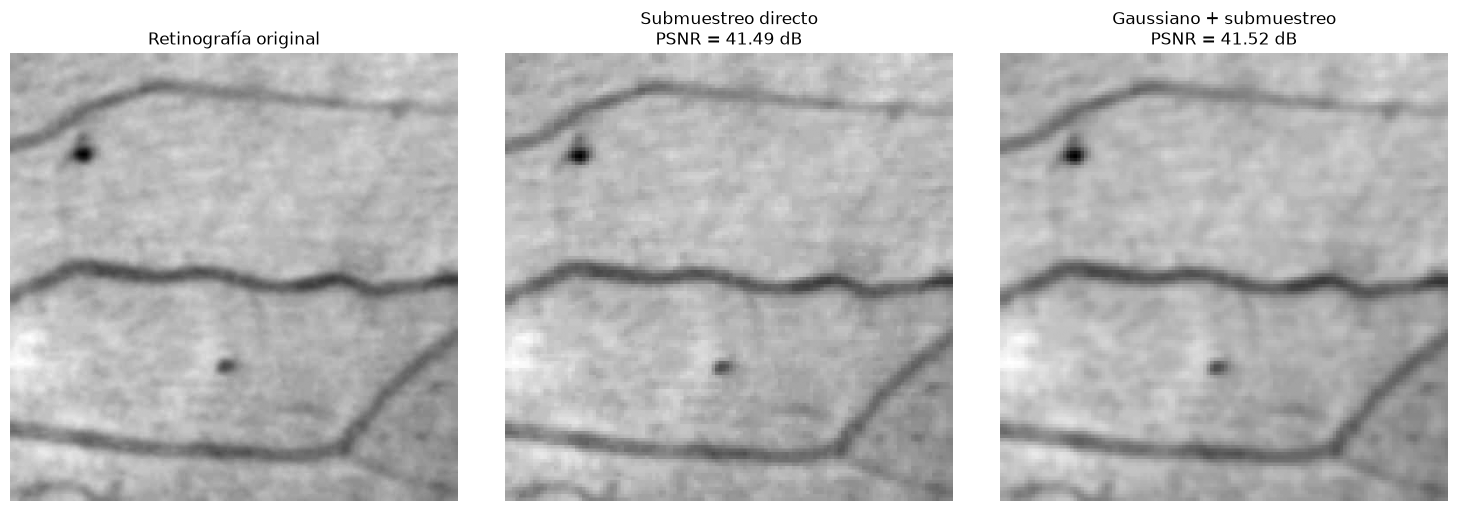

In [61]:
# ============================================================
# PARTE B - PUNTO 1: Carga de la retinografía
# ============================================================

# Se carga la imagen desde la carpeta indicada.
# cv2.imread() lee el archivo PNG y almacena sus píxeles
# en una matriz de NumPy.
retinografia = cv2.imread(
    "imagenes/retinografia_microaneurismas.png",
    cv2.IMREAD_GRAYSCALE
)

# ============================================================
# PARTE B - PUNTO 2: Reducción de resolución
# ============================================================

# Factor de submuestreo.
# S = 4 significa que se conservará una muestra de cada cuatro
# tanto en la dirección horizontal como en la vertical.
S = 4


# ------------------------------------------------------------
# MÉTODO 1: Submuestreo directo sin filtrado
# ------------------------------------------------------------

# Se toma una fila de cada 4 y una columna de cada 4.
# La imagen pasa de 512 x 512 a 128 x 128 píxeles.

retinografia_subsampled = retinografia[::S, ::S]


# ------------------------------------------------------------
# MÉTODO 2: Filtro Gaussiano + submuestreo
# ------------------------------------------------------------

# El enunciado establece que sigma = S / 2.
sigma = S / 2

# Se aplica primero un filtro Gaussiano para suavizar
# las variaciones espaciales rápidas antes del submuestreo.
#
# (0, 0) indica que OpenCV determina automáticamente
# el tamaño del kernel a partir de sigma.

retinografia_filtrada = cv2.GaussianBlur(
    retinografia,
    (0, 0),
    sigmaX=sigma
)

# Después del filtrado se toma una fila de cada 4
# y una columna de cada 4.
# La imagen resultante también tendrá 128 x 128 píxeles.

retinografia_subsampled_gaussian = retinografia_filtrada[::S, ::S]

# ============================================================
# PARTE B - PUNTO 3: Reescalado a la resolución original
# ============================================================

# Se define nuevamente el tamaño original de la imagen.
# OpenCV recibe el tamaño como (ancho, alto).
tamano_original = (512, 512)


# ------------------------------------------------------------
# Reescalado del submuestreo directo
# ------------------------------------------------------------

# cv2.resize() aumenta la imagen reducida de 128 x 128
# nuevamente a 512 x 512.
#
# INTER_NEAREST utiliza interpolación por vecino más cercano:
# cada nuevo píxel toma el valor del píxel más próximo.
#
# Este método no suaviza ni modifica los valores originales
# mediante promedios; simplemente replica muestras.

retinografia_directa_reescalada = cv2.resize(
    retinografia_subsampled,
    tamano_original,interpolation=cv2.INTER_NEAREST
)


# ------------------------------------------------------------
# Reescalado del submuestreo con filtro Gaussiano
# ------------------------------------------------------------

# Se realiza el mismo procedimiento para la imagen que fue
# filtrada con el Gaussiano antes del submuestreo.

retinografia_gaussiana_reescalada = cv2.resize(
    retinografia_subsampled_gaussian,
    tamano_original,interpolation=cv2.INTER_NEAREST
)

# ============================================================
# PARTE B - PUNTO 4: Cálculo de PSNR
# ============================================================

# Se calcula el PSNR entre la imagen original y la imagen
# obtenida mediante submuestreo directo.
psnr_directo = cv2.PSNR(
    retinografia,
    retinografia_directa_reescalada
)

# Se calcula el PSNR entre la imagen original y la imagen
# obtenida mediante filtro Gaussiano + submuestreo.
psnr_gaussiano = cv2.PSNR(
    retinografia,
    retinografia_gaussiana_reescalada
)

# Se muestran ambos resultados en decibelios (dB).
print(f"PSNR - Submuestreo directo: {psnr_directo:.2f} dB")
print(f"PSNR - Gaussiano + submuestreo: {psnr_gaussiano:.2f} dB")

# ============================================================
# PARTE B - VISUALIZACIÓN DE LOS RESULTADOS
# ============================================================

# Se crea una figura con 1 fila y 3 columnas.
# Cada columna mostrará una versión diferente de la retinografía.
fig, axes = plt.subplots(1, 3, figsize=(15, 5))


# ------------------------------------------------------------
# Imagen 1: Retinografía original
# ------------------------------------------------------------

# Se muestra la imagen original en escala de grises.
axes[0].imshow(retinografia, cmap="gray")

# Se agrega un título.
axes[0].set_title("Retinografía original")

# Se ocultan los ejes para facilitar la comparación visual.
axes[0].axis("off")


# ------------------------------------------------------------
# Imagen 2: Submuestreo directo
# ------------------------------------------------------------

# Se muestra la imagen reconstruida a 512 x 512 después
# del submuestreo directo.
axes[1].imshow(retinografia_directa_reescalada, cmap="gray")

# Se incluye el valor de PSNR obtenido para este método.
axes[1].set_title(
    f"Submuestreo directo\nPSNR = {psnr_directo:.2f} dB"
)

# Se ocultan los ejes.
axes[1].axis("off")


# ------------------------------------------------------------
# Imagen 3: Filtro Gaussiano + submuestreo
# ------------------------------------------------------------

# Se muestra la imagen reconstruida a 512 x 512 después
# de aplicar el filtro Gaussiano y realizar el submuestreo.
axes[2].imshow(retinografia_gaussiana_reescalada, cmap="gray")

# Se incluye el valor de PSNR obtenido para este método.
axes[2].set_title(
    f"Gaussiano + submuestreo\nPSNR = {psnr_gaussiano:.2f} dB"
)

# Se ocultan los ejes.
axes[2].axis("off")


# Se ajusta automáticamente el espacio entre las imágenes
# para evitar que los títulos se sobrepongan.
plt.tight_layout()

# Se muestra la figura completa.
plt.show()
